## **Welcome to my workshop titled "Leveraging artificial and human intelligence to understand human RL"! **
Sarah L. Master

08/18/2026

Tuebingen

In [ ]:
#@markdown Please run this cell and the next 4, then turn your attention to the lecture!

# Installs, imports, general variable initialization
!pip install git+https://github.com/deepmind/dm-haiku osfclient optax

import os
import pandas as pd
from osfclient import OSF
from google.colab import drive
import numpy as np
import scipy
import json
from tqdm import tqdm
import haiku as hk
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import seaborn as sns
import random

general_drive_directory = '/content/drive/'
drive.mount(general_drive_directory)

# Initialize these task-general variables.
max_n_arms = 6
max_n_states = 30

  Cloning https://github.com/deepmind/dm-haiku to /tmp/pip-req-build-lushdabq
  Running command git clone --filter=blob:none --quiet https://github.com/deepmind/dm-haiku /tmp/pip-req-build-lushdabq
  Resolved https://github.com/deepmind/dm-haiku to commit 4cd134acd2d50b06b4652b7fa9371e10486e9fa6
  Preparing metadata (setup.py) ... done
  Created wheel for dm-haiku: filename=dm_haiku-0.0.18.dev0-py3-none-any.whl size=376991 sha256=8ccf483d18996fc4abe96c60f0b23caa012b8c006e0a7863f69c1eb29a395920
  Stored in directory: /tmp/pip-ephem-wheel-cache-godni08e/wheels/9e/61/4f/80a3533070997bbf330ff52c178cc780d5e60ad222899e2924
Successfully built dm-haiku
Mounted at /content/drive/


In [ ]:
#@title Define helper functions

# Helper function for data formatting:
def format_data(file_list):
  # Get behavioral summary statistics, RNN model inputs, task labels, participant labels, etc.

  all_data = []
  X_labels_string = 'prev_choice, '*max_n_arms + 'choices_available, '*max_n_arms + 'prev_state, '*max_n_states + 'state, '*max_n_states + 'prev_reward'
  X_labels = [item for item in X_labels_string.split(', ')]

  print('Formatting data for models...')

  # Loop over all downloaded CSV files.
  for ii, csv_file in tqdm(enumerate(file_list), total=len(file_list)):

    # Read in as pandas DataFrame.
    try:
      df = pd.read_csv(csv_file)
    except:
      print('Issue in downloading ' + csv_file + ': it is blank. For now, skipping. Consider deleting & re-downloading this file.')
      continue

    # Before doing time-sensitive analyses e.g. learning curves,
    # ensure that every trial is the right order/place.
    # (Sometimes jsPsych has data saving issues on faulty/laggy servers.)
    df = df.sort_values(by='trial_index').reset_index(drop=True)

    # Count number of tasks each subject completed.
    if 'trial_epoch' in df.columns:
      n_tasks = len(df[df['trial_epoch']=='learn_choice']['session'].dropna().unique())
    else:
      # No tasks completed in this file!
      n_tasks = 0

    # Loop over each task to pull aggregate & trial-by-trial measures.
    for task in range(1,n_tasks):
      # Note that the range starts at 1 to prevent inclusion of the training task (0).
      # We do that here for model simplicity down the line, as the training task
      # is shorter than the other tasks (only 99 trials).

      per_task = dict()
      per_task['subject'] = df['participant_id'].iloc[0]
      per_task['run'] = ii
      per_task['session'] = task
      task_index = df['session']==task
      task_df = df[task_index]
      per_task['task_ID'] = task_df['task_number'].unique()[0]
      per_task['seed_ID'] = task_df['seed_number'].unique()[0]
      per_task['visibility_type'] = task_df['visibility_type'].unique()[0]
      per_task['n_actions'] = int(task_df['n_actions'].dropna().unique()[0])
      per_task['n_states'] = int(task_df['n_states'].dropna().unique()[0])
      per_task['points_type'] = task_df['points_type'].dropna().unique()[0]
      per_task['probs_type'] = task_df['probs_type'].dropna().unique()[0]
      per_task['points_relationship'] = task_df['points_relationship'].unique()[0]
      per_task['probs_relationship'] = task_df['probs_relationship'].unique()[0]
      per_task['block_change_type'] = task_df['block_change_type'].unique()[0]
      per_task['block_change_level'] = task_df['block_change_level'].unique()[0]

      # Grab trial-by-trial indices.
      choice_index = task_df['trial_epoch']=='learn_choice'
      n_trials = np.count_nonzero(choice_index)

      # Get the choice the human participants made on each trial.
      choices = np.array(task_df['arm_chosen'][choice_index].values,dtype=np.int64)

      # Grab trial-by-trial measures of how rewarding each arm is.
      arm_outcomes = [(json.loads(task_df['arm_outcomes'][choice_index].iloc[trial])) for trial in range(n_trials)]
      trial_maxes = [max(json.loads(task_df['arm_outcomes'][choice_index].iloc[trial])) for trial in range(n_trials)]

      # Grab trial-by-trial states and rewards.
      states = np.array(task_df['state'][choice_index].values,dtype=int)
      rewards = np.array(task_df['points_won'][choice_index].values,dtype=int)

      # Format these into inputs for the Q-learner!
      per_task['states'] = states
      per_task['rewards'] = rewards
      per_task['arm_outcomes'] = arm_outcomes
      per_task['choices'] = choices

      # Format these into inputs for the RNN!
      # NOTE: If you change the order of these matrices, then you'll need to
      # also change the order of the X labels created above!
      # First, grab choices and make them previous choices.
      X_choices = np.zeros((n_trials,max_n_arms))
      X_choices[np.arange(n_trials),choices] = 1
      X_prev_choices = np.roll(X_choices,1,axis=0)
      X_prev_choices[0,:] = 0
      X = X_prev_choices.copy()

      # Next, add choices available.
      X_choices_available = np.zeros((n_trials,max_n_arms))
      X_choices_available[:,:per_task['n_actions']] = 1
      X = np.concatenate((X,X_choices_available),axis=1)

      # Now, add states!
      X_states = np.zeros((n_trials,max_n_states))
      X_states[np.arange(n_trials),states] = 1
      X_prev_states = np.roll(X_states,1,axis=0)
      X = np.concatenate((X,X_states,X_prev_states),axis=1)

      # Finally, add rewards.
      prev_rewards = np.roll(rewards,1)
      prev_rewards[0] = 0
      # Reshape prev_rewards to be a 2D array (n_trials, 1) before concatenating
      X = np.concatenate((X,prev_rewards.reshape(-1, 1)),axis=1)
      per_task['X'] = X
      per_task['Y'] = choices
      per_task['X_labels'] = X_labels

      EV_arms = np.zeros((len(states),np.shape(arm_outcomes)[1]))
      best_arm = np.zeros(len(states),dtype=int)

      # Initialize container for learning curve arrays.
      per_task['learning_curves'], per_task['pct_accuracy_by_state'] = [], []

      # The best choice to make is dependent on the state you're in,
      # so loop over states to score subjects' choices.
      # Down the line we'll use these measures to make task-specific learning curves!
      for state in np.unique(states):

        # Grab relevant trials within-block.
        state_mask = task_df['state'][choice_index]==state
        state_index = np.where(state_mask)[0]

        # Grab relative state number within-block.
        within_block_state_index = int(state-np.min(states))

        # Finding the mean value of each arm in each state
        EV_arms[within_block_state_index] = np.mean([arm_outcomes[i] for i in state_index],axis=0)

        # Convert EV_arms back to the best choice on every trial.
        best_arm[state_index] = np.argmax(EV_arms[within_block_state_index])

        # Finally, grade each choice in each state! Was it the best possible choice?
        state_based_learning_curve = best_arm[state_mask] == choices[state_mask]
        per_task['learning_curves'].append(state_based_learning_curve)
        # per_task['EV_arms'].append(EV_arms)
        per_task['pct_accuracy_by_state'].append(np.mean(state_based_learning_curve))

      # Exit of by-state loop
      # Back to aggregrate task-wise variables
      per_task['chance'] = 1/per_task['n_actions']
      per_task['pct_accuracy'] = np.mean(per_task['pct_accuracy_by_state'])
      per_task['pct_accuracy_above_chance'] = per_task['pct_accuracy'] - per_task['chance']

      all_data.append(per_task)

  data_structure = pd.DataFrame(all_data)
  print('\nDone formatting!')
  return data_structure


# Helper function for plotting
def pull_average_learning_curve(learning_curves_list):
  # Pad learning curves to be the same shape despite differences in block length.
  max_len = 0
  all_lens = []
  for curves in learning_curves_list:
    for curve in curves:
      max_len = max(max_len, len(curve))

  padded_learning_curves = []
  for curves_for_subject in learning_curves_list:
      for curve in curves_for_subject:
        all_lens.append(len(curve))
        if type(curve)==list:
          padded_curve = curve + [np.nan] * (max_len - len(curve))
        else:
          padded_curve = list(curve) + [np.nan] * (max_len - len(curve))
        padded_learning_curves.append(padded_curve)

  # Take mean and standard error.
  learning_curves_array = np.array(padded_learning_curves)
  mean_learning_curve = np.nanmean(learning_curves_array, axis=0)
  se_learning_curve = np.nanstd(learning_curves_array, axis=0)/np.sqrt(len(learning_curves_array))
  mean_curve_length = np.nanmedian(all_lens)

  return mean_learning_curve, se_learning_curve, mean_curve_length

def train_test_split(data_struct,test_percentage):
  X = data_struct['X']
  Y = data_struct['Y']
  random_indices = np.random.permutation(len(X))
  test_size = int(len(X) * test_percentage)
  test_indices = random_indices[:test_size]
  train_indices = random_indices[test_size:]

  X_train_series = X.iloc[train_indices]
  X_test_series = X.iloc[test_indices]
  Y_train_series = Y.iloc[train_indices]
  Y_test_series = Y.iloc[test_indices]

  # Convert pandas Series of arrays to stacked numpy arrays
  X_train_stacked = np.stack(X_train_series.to_list())
  Y_train_stacked = np.stack(Y_train_series.to_list())
  X_test_stacked = np.stack(X_test_series.to_list())
  Y_test_stacked = np.stack(Y_test_series.to_list())

  # Convert numpy arrays to JAX arrays
  # Plus, remove first trial. (Problematic for prediction.)
  X_train_jax = jnp.array(X_train_stacked[:,1:,:])
  Y_train_jax = jnp.array(Y_train_stacked[:,1:])
  X_test_jax = jnp.array(X_test_stacked[:,1:,:])
  Y_test_jax = jnp.array(Y_test_stacked[:,1:])

  return X_train_jax, X_test_jax, Y_train_jax, Y_test_jax


## Load Data from OSF

In the following cell, we will grab the [Azulejos dataset from OSF.](https://osf.io/g2ds8/overview) We are going to save the data to our personal Drive accounts (don't worry - it's not very big!) in order to work with it through CoLab.

Want to know more about the dataset, or how it was collected? Check out [this README.](https://osf.io/g2ds8/overview)

In [ ]:
#@title Specify where the data will be saved within your Drive - then download!

subdirectory = 'azulejos/OSF/' #@param

# Note: We restrict download batch size to 100 files at a time.
# Downloading all 419 files is possible, too, but it takes upwards of 15 minutes.
download_batch_size = 100
downloaded_count = 0

# Construct the full path for the subdirectory in Google Drive
drive_subdirectory_path = os.path.join(general_drive_directory, 'MyDrive', subdirectory)

# Ensure the directory exists. Added exist_ok=True to prevent errors if already exists.
os.makedirs(drive_subdirectory_path, exist_ok=True)
print(f"Ensured directory exists: {drive_subdirectory_path}")

downloaded_files = [os.path.join(drive_subdirectory_path, f) for f in os.listdir(drive_subdirectory_path) if f.endswith('csv')]

osf = OSF()
project = osf.project('g2ds8')  # Project ID is specific to Azulejos OSF

for storage in project.storages:
  # Convert the generator to a list to get its length
  all_files_in_storage = list(storage.files)
  all_csvs_in_storage = [file_ for file_ in all_files_in_storage if file_.name.endswith('.csv')]
  print('Found ' + str(len(all_csvs_in_storage)) + ' files on the OSF directory.')
  print(str(len(downloaded_files)) + ' files have already been downloaded.')

  if (len(all_csvs_in_storage) - len(downloaded_files)) < download_batch_size:
    download_batch_size = len(all_csvs_in_storage) - len(downloaded_files)

  print('Beginning download of ' + str(download_batch_size) + ' files.')
  for file_ in all_csvs_in_storage:
    # Define the full path where the file will be saved in Google Drive
    file_path_in_drive = os.path.join(drive_subdirectory_path, file_.name)

    if os.path.exists(file_path_in_drive):
      # This file has already been downloaded to Drive. Moving on.
      if file_path_in_drive not in downloaded_files:
        downloaded_files.append(file_path_in_drive)
    else:
      # Open a local file in binary write mode and get content from OSF file object
      with open(file_path_in_drive, 'wb') as local_file:
        file_.write_to(local_file)
      print(f"Saved {file_.name} to {file_path_in_drive}")

      downloaded_files.append(file_path_in_drive)
      downloaded_count += 1
      if downloaded_count == download_batch_size:
        break

# Load the first downloaded CSV file into a pandas DataFrame as an example
if downloaded_files:
    print(f"\nLoading the first downloaded file: {downloaded_files[0]} into a DataFrame...")
    df_first_file = pd.read_csv(downloaded_files[0])
    print("First 5 rows of the DataFrame:")
    display(df_first_file.head())
else:
    print("No CSV files were downloaded from the OSF project.")

Ensured directory exists: /content/drive/MyDrive/azulejos/OSF/
Found 419 files on the OSF directory.
359 files have already been downloaded.
Beginning download of 60 files.


100%|██████████| 3.35M/3.35M [00:00<00:00, 8.46Mbytes/s]


Saved run8.csv to /content/drive/MyDrive/azulejos/OSF/run8.csv


100%|██████████| 3.23M/3.23M [00:00<00:00, 7.84Mbytes/s]


Saved run239.csv to /content/drive/MyDrive/azulejos/OSF/run239.csv


...

100%|██████████| 3.36M/3.36M [00:00<00:00, 8.60Mbytes/s]


Saved run56.csv to /content/drive/MyDrive/azulejos/OSF/run56.csv


100%|██████████| 3.21M/3.21M [00:00<00:00, 7.90Mbytes/s]


Saved run101.csv to /content/drive/MyDrive/azulejos/OSF/run101.csv

Loading the first downloaded file: /content/drive/MyDrive/azulejos/OSF/run71.csv into a DataFrame...
First 5 rows of the DataFrame:


,participant_id,rt,stimulus,response,trial_index,time_elapsed,recorded_at,total_time_on_task,trial_epoch,task_trial_num,...,probs_type,probs_relationship,block_change_level,block_change_type,random_walk_sigma_o,random_walk_sigma_d,random_walk_lambd,random_walk_theta,arm_points,arm_probs
0,424,7193.0,\n <p>Welcome to our experiment!</p>\n <p>Yo...,enter,0,7196,2025-06-06 12:16:06,2881257,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,424,6630.0,\n<p><strong>Consent form</strong></p>\n\n<p>I...,0,1,13827,2025-06-06 12:16:06,2881257,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,424,NaN,NaN,NaN,2,13873,2025-06-06 12:16:06,2881257,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,424,126082.0,NaN,NaN,3,139955,2025-06-06 12:16:06,2881257,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,424,NaN,NaN,NaN,4,140002,2025-06-06 12:16:06,2881257,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#@title Format data for use in RNN and other models, as well as for basic behavioral analyses.

downloaded_files = [os.path.join(drive_subdirectory_path, f) for f in os.listdir(drive_subdirectory_path) if f.endswith('csv')]

data = format_data(downloaded_files)

Formatting data for models...


 27%|██▋       | 109/400 [00:30<00:35,  8.10it/s]

Issue in downloading /content/drive/MyDrive/azulejos/OSF/run60.csv: it is blank. For now, skipping. Consider deleting & re-downloading this file.


 65%|██████▌   | 260/400 [00:57<00:17,  8.11it/s]

Issue in downloading /content/drive/MyDrive/azulejos/OSF/run301.csv: it is blank. For now, skipping. Consider deleting & re-downloading this file.


100%|██████████| 400/400 [01:21<00:00,  4.88it/s]


Done formatting!


In [ ]:
#@title **Understanding the AZULEJOS dataset.**

#@markdown Pause here, so we can start out by getting a feel for the data.

#@markdown The **Azulejos** dataset is a large-scale, comprehensive collection of human behavior on reinforcement learning (RL) bandit tasks. Developed to bridge the gaps between the isolated experiments in the literature on human RL, this dataset provides over 3.3 million human choices across a vast, continuous space of 10,805 unique task configurations. That is, the Azulejos bandits tile bandit task space, just like beautiful Azulejos tile many historic buildings in Portugal and Spain.

#@markdown In this workshop, we're going to work with a small subset of the dataset (100-400 files, instead of 3,177).

#@markdown Every task in the dataset is an RL bandit, but the similarities stop there. The tasks vary in superficial ways, like what is displayed on screen or how feedback is presented, and in fundamental ways, like how much information there is to learn in each task block or what changes across task blocks.

#@markdown What can computational models tell us about human behavior on these diverse tasks?

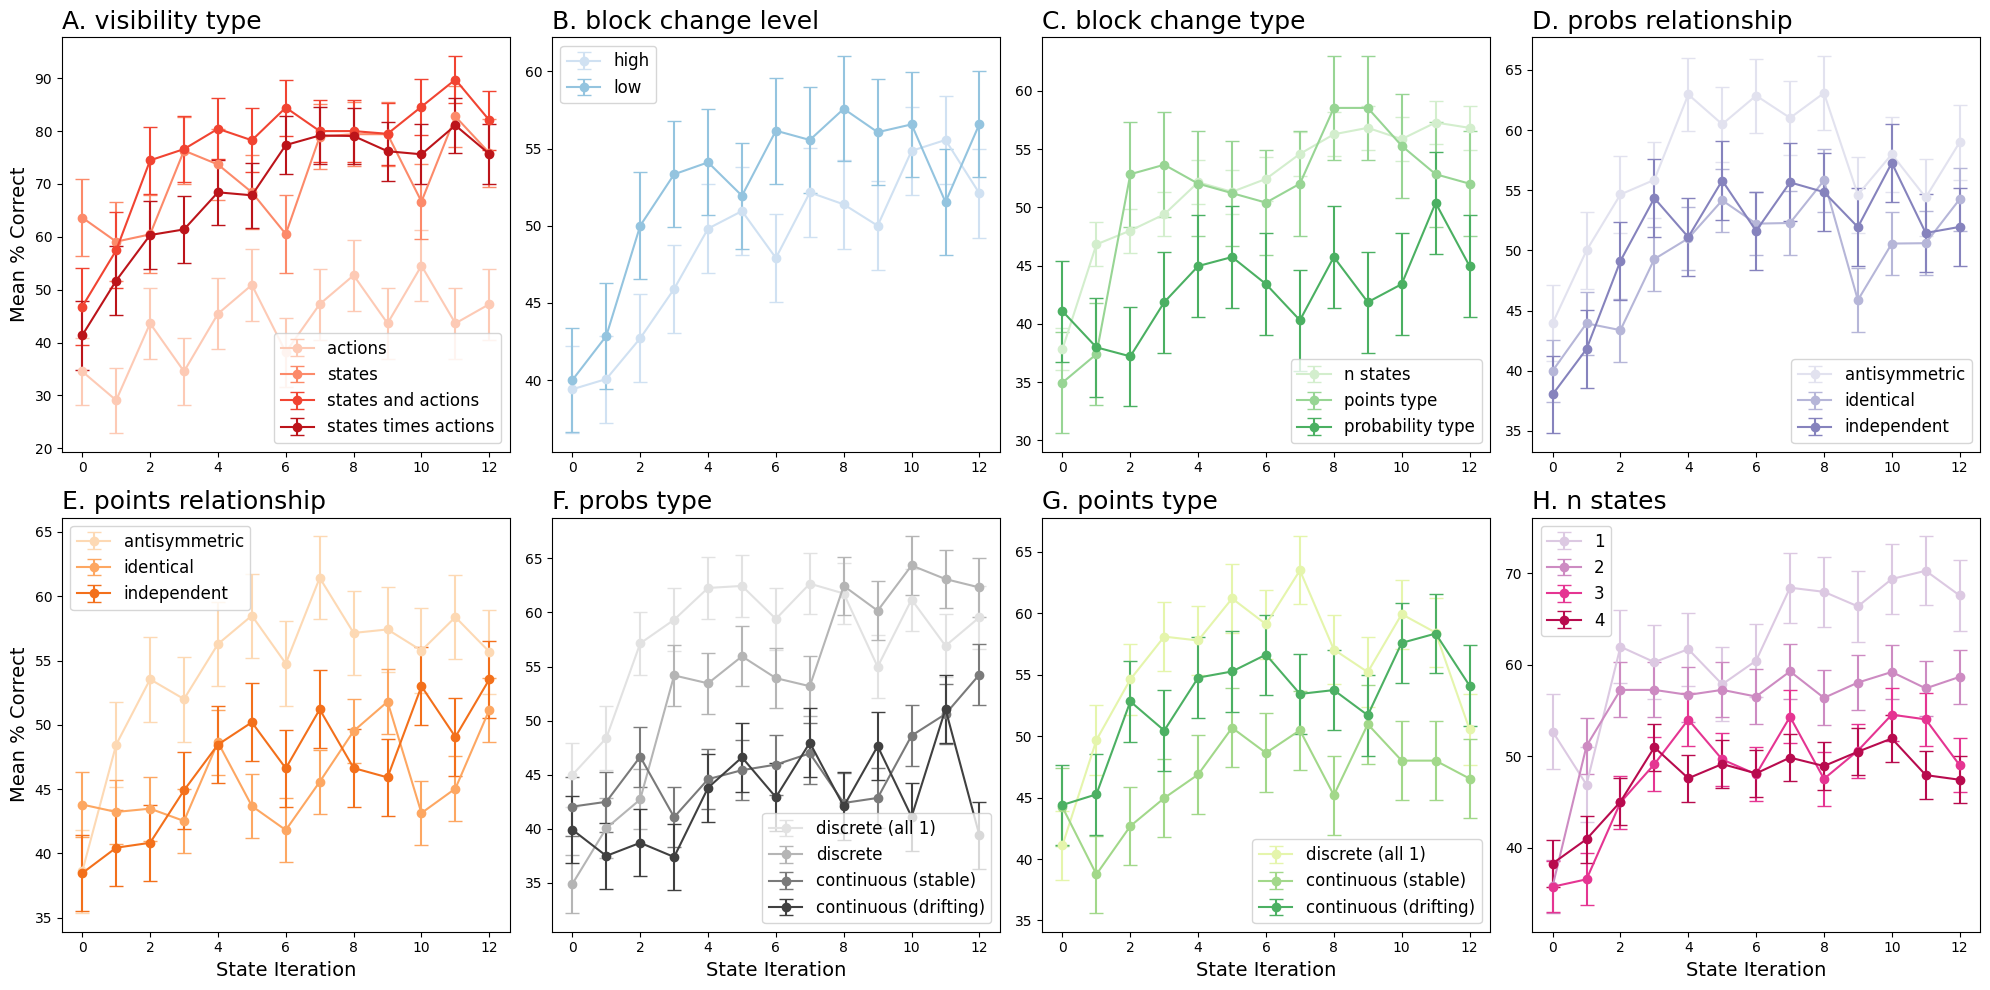

In [ ]:
#@title Compare learning curves across task conditions

features_of_interest = ['visibility_type', 'block_change_level', 'block_change_type', 'probs_relationship',
                         'points_relationship', 'probs_type', 'points_type', 'n_states']
subplot_titles = ['A.', 'B.', 'C.', 'D.', 'E.', 'F.', 'G.', 'H.']
color_strings = ['Reds', 'Blues', 'Greens', 'Purples', 'Oranges', 'Greys', 'YlGn', 'PuRd', 'hot']

dependent_variable = 'learning_curves'
y_label = 'Mean % Correct'
x_label = 'State Iteration'
short_name = 'best_choice_'
constant = 100

fig, ax = plt.subplots(figsize=[20,10],nrows=2,ncols=4)
ax = ax.flatten()

for ii,feature_of_interest in enumerate(features_of_interest):

  cmap = plt.get_cmap(color_strings[ii], 6)
  color_list = [cmap(i) for i in range(1,7)]

  # Which settings are allowed within this feature?
  settings = np.sort(data[feature_of_interest].dropna().unique())
  if feature_of_interest == 'n_states':
    settings = [1,2,3,4]
  elif feature_of_interest == 'points_type':
    settings = ['all_1','continuous_and_stable','continuous_and_drifting']
  elif feature_of_interest == 'probs_type':
    settings = ['all_1','binary_and_stable','continuous_and_stable','continuous_and_drifting']

  # First, remove over-sampled tasks, because they really add STRONG dependencies between the variables being plotted here.
  data_edited = data.drop(data[(data['task_ID']<9)].index)

  # Now if you want a more or less pure measure of the effect of one task variable on the learning curves,
  # you should standardize the number of instances of each other task variable.

  # One simple thing to do is to limit the distribution of n_actions
  # to the distribution contained within the least frequent setting.
  # This will both 1) standardize chance level and
  # 2) standardize the amount of data per line, for easier comparison.

  # You could also imagine wanting to do this for other task features.

  feature_to_standardize = 'n_actions'
  settings_to_standardize = np.sort(data_edited[feature_to_standardize].dropna().unique())

  counts = []
  for setting in settings_to_standardize:
    counts.append(np.shape(np.where(data_edited[feature_to_standardize]==setting))[1])

  size_of_set = counts[3]
  subsample_mask = np.zeros(len(data_edited), dtype=bool)
  for setting in settings:
    index = np.where(data_edited[feature_of_interest]==setting)[0]
    random_subsample = np.random.choice(index, size=size_of_set, replace=False)
    subsample_mask[random_subsample] = True

  data_edited = data_edited[subsample_mask]

  # Enumerate settings
  min_block_length = 200
  for jj,setting in enumerate(settings):

    learning_curves_list = []

    # If feature to examine is visibility, standardize to single-state tasks only.
    # Easier comparison across single-state tasks in this instance.
    if feature_of_interest == 'visibility_type':
      index = (data_edited[feature_of_interest]==setting) & (data_edited['n_states']==1)
    else:
      index = (data_edited[feature_of_interest]==setting)

    # Convert to list.
    learning_curves_list = data_edited[dependent_variable][index].tolist()

    mean_learning_curve, se_learning_curve, mean_block_length = pull_average_learning_curve(learning_curves_list)
    min_block_length = min(min_block_length, mean_block_length)
    legend_label = str(setting)

    # Do a little label editing for clarity.
    legend_label = legend_label.replace('_',' ')
    legend_label = legend_label.replace('probs', 'probability')
    legend_label = legend_label.replace('visibility type', 'visible')

    if 'points_type' in feature_of_interest or 'probs_type' in feature_of_interest:
      if 'continuous_and_stable' in setting:
        legend_label = legend_label.replace('continuous and stable','continuous (stable)')
      elif 'continuous_and_drifting' in setting:
        legend_label = legend_label.replace('continuous and drifting','continuous (drifting)')
      elif 'binary_and_stable' in setting:
        legend_label = legend_label.replace('binary and stable','discrete')
      elif 'all_1' in setting:
        legend_label = legend_label.replace('all 1','discrete (all 1)')

    # Plot!
    # Editing out non-existent task settings:
    if len(learning_curves_list)>1:
      n_trials_to_plot = 13 # standardize the length of curves
      ax[ii].errorbar(np.arange(n_trials_to_plot), mean_learning_curve[:n_trials_to_plot]*constant,
                  yerr=se_learning_curve[:n_trials_to_plot]*constant, fmt='-o', capsize=5,
                  label=legend_label, color=color_list[jj])
      if ii > 3:
        ax[ii].set_xlabel(x_label,fontsize=14)
      if ii % 4 == 0:
        ax[ii].set_ylabel(y_label,fontsize=14)
      ax[ii].legend(fontsize=12)
      ax[ii].set_title(subplot_titles[ii] + ' ' + feature_of_interest.replace('_',' '), loc='left', fontsize=18)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels

plt.show()

In [ ]:
#@title What can RNN models of behavior tell us?

#@markdown RNN's are maximally flexible, complex, and uninterpretable. They are too big and complex to easily understand.

#@markdown So, they can't be a *theory* of human RL, like traditional computational models can.

#@markdown What can they do for us?

#@markdown For one, they can describe *how* predictable our dataset is. If there's a predictable pattern in your data, then an RNN will find it. They can therefore be useful for comparing to different models. If a smaller, less complex model can reach RNN prediction ability (a "ceiling"), then it's an amazing model.

#@markdown Let's get a sense for fitting RNN models and finding our ceiling.

In [ ]:
#@title "Create" our RNNs (GRUs)

# First, let's define the functions that will make up our RNNs.
# 1. Define the Haiku module for the neural network (Gated Recurrent Unit)
class GRUModel(hk.Module):
  def __init__(self, hidden_size: int, name=None):
    super().__init__(name=name)
    self.gru = hk.GRU(hidden_size) # GRU layer
    self.output_layer = hk.Linear(max_n_arms) # Output linear layer for classification

  def __call__(self, x: jnp.ndarray, state: jnp.ndarray | None = None):
    # x is expected to be (sequence_length, input_features)
    # or (batch_size, sequence_length, input_features) if using vmap

    # Initialize state if not provided (typically all zeros)
    if state is None:
      # Initialize state with zeros for the given hidden_size
      state = self.gru.initial_state(x.shape[0]) if len(x.shape) == 3 else self.gru.initial_state(1)

    # Unroll the GRU over the sequence
    outputs, final_state = hk.dynamic_unroll(self.gru, x, state, time_major=False) # x is (batch, time, features)

    # For classification, we often use the output of the last step
    # or the final hidden state. Let's use the final output sequence here.
    # The output layer maps the GRU's output at each time step to logits.
    logits = self.output_layer(outputs)
    return logits # (batch, sequence_length, output_size)

# 2. Transform the Haiku module into a pure function
def forward_fn(x: jnp.ndarray):
  # The input x for the GRU will be (batch_size, sequence_length, input_features)
  # The output size is 6 for categorical prediction (1-6).
  # Let's say we want to predict for each step in the sequence.
  hidden_size = 32 # Example hidden layer size for the GRU
  return GRUModel(hidden_size, name="gru_model")(x)

transform_fn = hk.without_apply_rng(hk.transform(forward_fn))

# 3. Define the loss function (softmax cross-entropy)
def loss_fn(params, x, y_true):
  # logits will be (batch_size, sequence_length, output_size)
  logits = transform_fn.apply(params, x)

  # y_true is (batch_size, sequence_length), values 1-6
  # We need to reshape y_true for optax to match logits' shape for element-wise loss
  labels_sparse = y_true

  # Compute loss for each step in the sequence using the masked logits.
  # logits: (batch, seq_len, num_classes)
  # labels_sparse: (batch, seq_len)
  loss_per_step = optax.softmax_cross_entropy_with_integer_labels(logits=logits, labels=labels_sparse)
  return jnp.mean(loss_per_step) # Average loss over all steps and batch items

# 4. Define a normalized log likelihood function.
@jax.jit
def categorical_neg_log_likelihood(labels: jnp.ndarray, output_logits: jnp.ndarray, valid_actions_masks: jnp.ndarray | None = None) -> tuple[jnp.ndarray, jnp.ndarray]:
  # 1. Per-trial mask: True where a choice was actually made
  mask = jnp.logical_not(labels < 0)  # (n_trials, n_sessions, 1)

  # 2. Compute (masked) log-softmax
  if valid_actions_masks is not None:
    masked_logits = jnp.where(valid_actions_masks, output_logits, -jnp.inf)
  else:
    masked_logits = output_logits
  log_probs = jax.nn.log_softmax(masked_logits, axis=-1)

  # 3. Gather the log-prob of the chosen action via one-hot
  one_hot_labels = jax.nn.one_hot(
      labels[:, :, 0], num_classes=output_logits.shape[-1]
  )  # (n_trials, n_sessions, n_classes)
  log_liks = one_hot_labels * log_probs
  masked_log_liks = jnp.where(mask, log_liks, 0.0)

  total_nll = -jnp.sum(masked_log_liks)
  n_valid = jnp.sum(mask)
  avg_nll = total_nll / n_valid
  return avg_nll, n_valid

# 4.5. Helper function for categorical_neg_log_likelihood
# Format things to be in right shape for above function...
def collect_nllh(params, X_test, Y_test):
  X_labels = data.X_labels[0]
  arms_available_mask = np.array([label == 'choices_available' for label in X_labels])

  # Reshape Y_test to (batch_size, sequence_length, 1) to match the expected labels format
  Y_test_reshaped = Y_test.reshape(Y_test.shape[0], Y_test.shape[1], 1)

  # Extract the choices_available mask from X_test.
  # X_test has shape (batch_size, sequence_length, n_features).
  # X_test[:,:,arms_available_mask] selects the features corresponding to 'choices_available',
  # resulting in a tensor of shape (batch_size, sequence_length, max_n_arms)
  # containing 0s and 1s, which acts as the valid_actions_masks.
  choices_available_input_mask = X_test[:,:,arms_available_mask]

  nllh, n_valid_actions = categorical_neg_log_likelihood(Y_test_reshaped, transform_fn.apply(params, X_test), choices_available_input_mask)

  return nllh

# 5. Define the update function (training step)
def _update_fn_raw(params, opt_state, optimizer, x, y_true):
  loss, grads = jax.value_and_grad(loss_fn)(params, x, y_true)
  updates, opt_state = optimizer.update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state, loss

update_fn = jax.jit(_update_fn_raw, static_argnums=2)

In [ ]:
#@title **Fit an example RNN!**

# Set Hyperparameters

# Set the learning rate of the network. High learning rates will result in fast learning, low will result in incremental learning.
# Why might we want a fast or slow learning regime?
learning_rate = 1e-3

# Set the number of training epochs (data re-presentations) for the network to experience.
num_epochs = 5

# Split data into train & test sets.
test_percentage = 0.2
X_train, X_test, Y_train, Y_test = train_test_split(data, test_percentage=test_percentage)

# Initialize, then train the network!
def init_and_train_network(learning_rate, num_epochs):

  # Initialize a random seed for the random weight initializations.
  seed = jax.random.PRNGKey(95)

  # Initialize model parameters with the correct shape and JAX array type
  params = transform_fn.init(seed, X_train)

  # Initialize optimizer
  optimizer = optax.inject_hyperparams(optax.adam)(learning_rate)
  opt_state = optimizer.init(params)

  print(f"Starting training for {num_epochs} epochs...")

  # Training loop
  training_loss, testing_loss = [], []
  for epoch in range(num_epochs):
    current_test_loss = loss_fn(params, X_test, Y_test)
    params, opt_state, current_train_loss = update_fn(params, opt_state, optimizer, X_train, Y_train)
    training_loss.append(current_train_loss)
    testing_loss.append(current_test_loss)
    print(f"Epoch {epoch + 1}, Train Loss: {current_train_loss:.4f}, Test Loss: {current_test_loss:.4f}")

  print("Training complete!")
  return training_loss, testing_loss, params

training_loss, testing_loss, params = init_and_train_network(learning_rate,num_epochs)


Starting training for 5 epochs...
Epoch 1, Train Loss: 1.6830, Test Loss: 1.7012
Epoch 2, Train Loss: 1.6561, Test Loss: 1.6740
Epoch 3, Train Loss: 1.6310, Test Loss: 1.6485
Epoch 4, Train Loss: 1.6073, Test Loss: 1.6247
Epoch 5, Train Loss: 1.5849, Test Loss: 1.6022
Training complete!


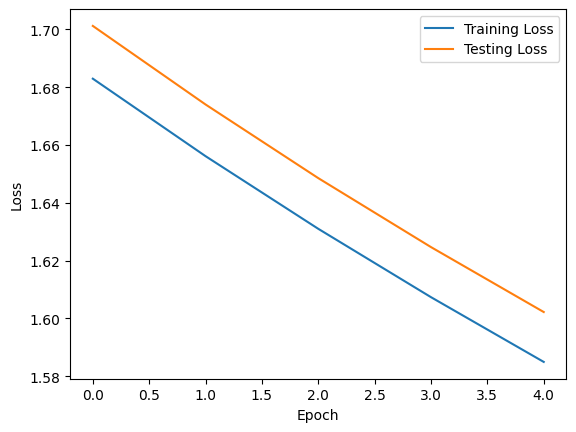

In [ ]:
#@title Examine training and testing loss.
plt.figure()
plt.plot(training_loss, label='Training Loss')
plt.plot(testing_loss, label='Testing Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#@markdown What's the difference between training loss and testing loss?

#@markdown Training loss refers to the degree of error the network produces in trying to predict the data it's being trained on. This can reflect both when the network is picking up on patterns in the data, but also when the network is memorizing the training data (i.e. over-fitting!).

#@markdown Testing loss refers to the degree of error the network produces in trying to predict a set of test data - AKA data "held out" from the network. This only reflects that the network is picking up on general patterns in the data. Testing loss is therefore a better metric for whether the network is learning something "real" about the dataset.

#@markdown So, is there something the network is learning / picking up on? How could we tell?

Starting training for 50 epochs...
Epoch 1, Train Loss: 1.6830, Test Loss: 1.7012
Epoch 2, Train Loss: 1.5044, Test Loss: 1.5176
Epoch 3, Train Loss: 1.4091, Test Loss: 1.4297
Epoch 4, Train Loss: 1.3826, Test Loss: 1.4079
Epoch 5, Train Loss: 1.3589, Test Loss: 1.3854
Epoch 6, Train Loss: 1.3341, Test Loss: 1.3598
Epoch 7, Train Loss: 1.3183, Test Loss: 1.3417
Epoch 8, Train Loss: 1.3124, Test Loss: 1.3321
Epoch 9, Train Loss: 1.3121, Test Loss: 1.3277
Epoch 10, Train Loss: 1.3075, Test Loss: 1.3207
Epoch 11, Train Loss: 1.2965, Test Loss: 1.3087
Epoch 12, Train Loss: 1.2845, Test Loss: 1.2966
Epoch 13, Train Loss: 1.2744, Test Loss: 1.2869
Epoch 14, Train Loss: 1.2640, Test Loss: 1.2773
Epoch 15, Train Loss: 1.2518, Test Loss: 1.2649
Epoch 16, Train Loss: 1.2417, Test Loss: 1.2540
Epoch 17, Train Loss: 1.2321, Test Loss: 1.2426
Epoch 18, Train Loss: 1.2182, Test Loss: 1.2290
Epoch 19, Train Loss: 1.2097, Test Loss: 1.2212
Epoch 20, Train Loss: 1.2026, Test Loss: 1.2124
Epoch 21, Trai

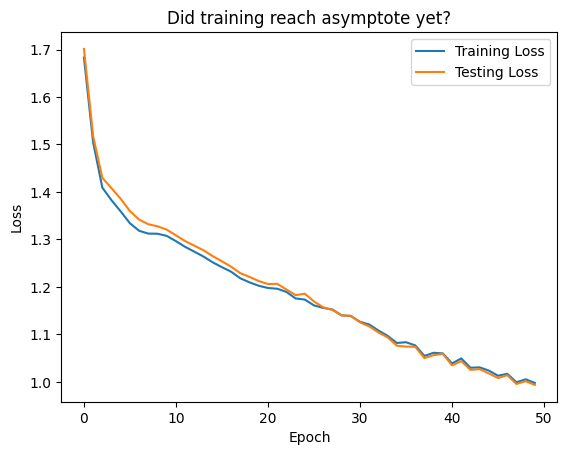

In [ ]:
#@title Hmmm... Did the training reach asymptote? Did the network learn all that it can?

#@markdown How might we play around with the network hyper-parameters to get asymptotic loss, but without getting overfitting?

# Hyperparameters

# Set the learning rate of the network.
learning_rate = 1e-2 #@param

# Set the number of training epochs.
num_epochs = 50 #@param

# Initialize, then train the network!
training_loss, testing_loss, params = init_and_train_network(learning_rate,num_epochs)

#Examine training and testing loss.
plt.figure()
plt.plot(training_loss, label='Training Loss')
plt.plot(testing_loss, label='Testing Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Did training reach asymptote yet?')
plt.legend()
plt.show()

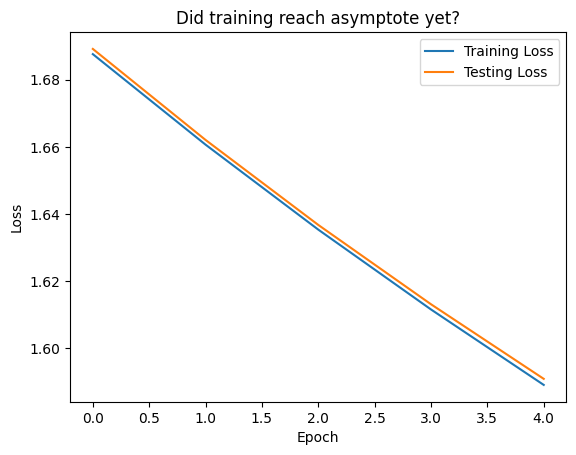

In [ ]:
#@title Bonus! Adapt the following function to continue training a neural net, instead of re-initializing anew.

# Initialize, then train the network!
def train_network(learning_rate, num_epochs):
  # Initialize a random seed for the random weight initializations.
  seed = jax.random.PRNGKey(95)

  # Initialize model parameters with the correct shape and JAX array type
  params = transform_fn.init(seed, X_train)

  # Initialize optimizer
  optimizer = optax.inject_hyperparams(optax.adam)(learning_rate)
  opt_state = optimizer.init(params)

  print(f"Starting training for {num_epochs} epochs...")

  # Training loop
  training_loss, testing_loss = [], []
  for epoch in range(num_epochs):
    current_test_loss = loss_fn(params, X_test, Y_test)
    params, opt_state, current_train_loss = update_fn(params, opt_state, optimizer, X_train, Y_train)
    training_loss.append(current_train_loss)
    testing_loss.append(current_test_loss)
    print(f"Epoch {epoch + 1}, Train Loss: {current_train_loss:.4f}, Test Loss: {current_test_loss:.4f}")

  print("Training complete!")
  return training_loss, testing_loss, params

# Uncomment this when the function has been adapted!

# more_training_loss, more_testing_loss, params = train_network(learning_rate,num_epochs)

#training_loss = training_loss.append(more_training_loss)
#testing_loss = testing_loss.append(more_testing_loss)

#Examine training and testing loss.
plt.figure()
plt.plot(training_loss, label='Training Loss')
plt.plot(testing_loss, label='Testing Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Did training reach asymptote yet?')
plt.legend()
plt.show()

In [ ]:
#@title Okay, so there's something to predict in our dataset! What else can we learn from an RNN model?

#@markdown One thing we can do is use RNNs to find where there are pattern matches or MISMATCHES in subsections of our data.

#@markdown What do I mean by that? I mean that once an RNN identifies a behavioral pattern in one dataset, it can be applied to predicting behavioral patterns in another dataset. If there isn't a lot of generalizable information from one chunk of the data to the next, then that suggests that people are behaving quite differently across those chunks of the data.

#@markdown Under what settings would we predict big differences in behavior?

#@markdown Well, certainly when there are big differences between tasks, right?


In [ ]:
#@title Let's examine some task differences that may or may not produce very different human behavior.

# Let's select a different training / test split.

# How about we examine tasks with slightly different numbers of states?

# These tasks have 2 states.
data_2_states = data.loc[data['n_states']==2]

# These tasks have 3 states.
data_3_states = data.loc[data['n_states']==3]


In [ ]:
#@title How to examine? We'll fit two neural nets, one to each data split, and then we'll evaluate them on each other.

# The end product will be a confusion matrix, demonstrating how well a neural net fit to one section of data generalizes in predicting behavior in another section.

# Split each dataset into training and testing sets.
two_X_train, two_X_test, two_Y_train, two_Y_test = train_test_split(data_2_states, test_percentage=0.2)
three_X_train, three_X_test, three_Y_train, three_Y_test = train_test_split(data_3_states, test_percentage=0.2)

# Initialize, then train each network.
in_sample_test_loss, out_sample_test_loss = [], []

# Initialize the X_train, X_test, etc., globals.
X_train, X_test, Y_train, Y_test = train_test_split(data_2_states, test_percentage=0.2)

training_loss, testing_loss, params = init_and_train_network(learning_rate,num_epochs)
in_sample_test_loss.append(collect_nllh(params, two_X_test, two_Y_test))
out_sample_test_loss.append(collect_nllh(params, three_X_test, three_Y_test))

# Initialize the X_train, X_test, etc., globals again.
X_train, X_test, Y_train, Y_test = train_test_split(data_3_states, test_percentage=0.2)

training_loss, testing_loss, params = init_and_train_network(learning_rate,num_epochs)
in_sample_test_loss.append(collect_nllh(params, three_X_test, three_Y_test))
out_sample_test_loss.append(collect_nllh(params, two_X_test, two_Y_test))

Starting training for 50 epochs...
Epoch 1, Train Loss: 1.6626, Test Loss: 1.6456
Epoch 2, Train Loss: 1.4624, Test Loss: 1.4305
Epoch 3, Train Loss: 1.3544, Test Loss: 1.3180
Epoch 4, Train Loss: 1.3190, Test Loss: 1.2822
Epoch 5, Train Loss: 1.2968, Test Loss: 1.2603
Epoch 6, Train Loss: 1.2765, Test Loss: 1.2405
Epoch 7, Train Loss: 1.2624, Test Loss: 1.2276
Epoch 8, Train Loss: 1.2537, Test Loss: 1.2192
Epoch 9, Train Loss: 1.2516, Test Loss: 1.2171
Epoch 10, Train Loss: 1.2482, Test Loss: 1.2148
Epoch 11, Train Loss: 1.2398, Test Loss: 1.2086
Epoch 12, Train Loss: 1.2324, Test Loss: 1.2038
Epoch 13, Train Loss: 1.2302, Test Loss: 1.2039
Epoch 14, Train Loss: 1.2289, Test Loss: 1.2043
Epoch 15, Train Loss: 1.2234, Test Loss: 1.1997
Epoch 16, Train Loss: 1.2152, Test Loss: 1.1921
Epoch 17, Train Loss: 1.2074, Test Loss: 1.1849
Epoch 18, Train Loss: 1.2007, Test Loss: 1.1783
Epoch 19, Train Loss: 1.1949, Test Loss: 1.1729
Epoch 20, Train Loss: 1.1837, Test Loss: 1.1636
Epoch 21, Trai

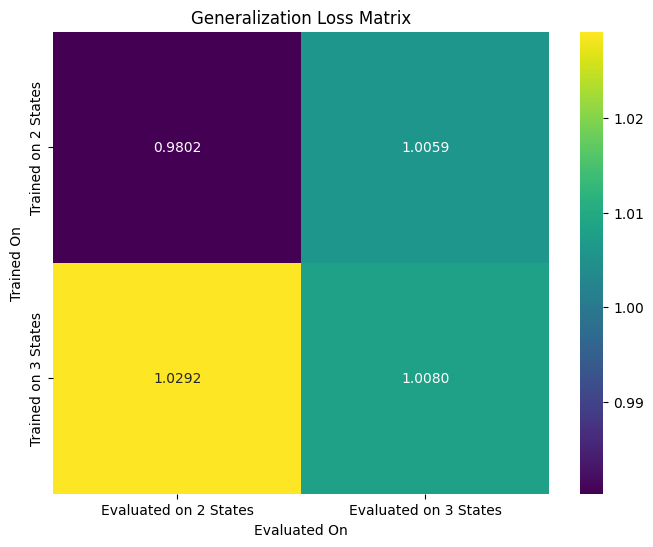

In [ ]:
#@title Plot Generalization Loss Matrix!

#@markdown What have we learned?

#@markdown Does behavior on one set of tasks resemble behavior on another set?

# Construct the 2x2 matrix for generalization loss
# Row 0: Network 1 (trained on 2 states data) evaluated on both kinds of data
# Row 1: Network 2 (trained on 3 states data) evaluated on both kinds og data
generalization_loss_matrix = [
    [in_sample_test_loss[0], out_sample_test_loss[0]],
    [out_sample_test_loss[1], in_sample_test_loss[1]]
]

# Define the labels for the x and y axes
x_labels = ['Evaluated on 2 States', 'Evaluated on 3 States']
y_labels = ['Trained on 2 States', 'Trained on 3 States']

plt.figure(figsize=(8, 6))
sns.heatmap(generalization_loss_matrix, annot=True, fmt=".4f", cmap="viridis",
            xticklabels=x_labels, yticklabels=y_labels)
plt.title('Generalization Loss Matrix')
plt.xlabel('Evaluated On')
plt.ylabel('Trained On')
plt.show()

In [ ]:
#@title Okay, so behavior isn't very clearly changed by that task feature.

# What's a more interesting task feature we can examine?

# What about the type of feedback subjects receive? Does behavior change broadly when feedback is deterministic versus stochastic?

# These tasks only have actions visible on screen.
data_probabilistic = data.loc[(data['probs_type']=='continuous_and_drifting') | (data['visibility_type']=='continuous_and_stable')]

# These tasks have states visible as well.
data_deterministic = data.loc[(data['probs_type']=='all_1') | (data['visibility_type']=='binary_and_stable')]

In [ ]:
#@title What about a different task feature? Let's try the same analysis.

# The end product will be a confusion matrix, demonstrating how well a neural net fit to one section of data generalizes in predicting behavior in another section.

# Split each dataset into training and testing sets.
probabilistic_X_train, probabilistic_X_test, probabilistic_Y_train, probabilistic_Y_test = train_test_split(data_probabilistic, test_percentage=0.2)
deterministic_X_train, deterministic_X_test, deterministic_Y_train, deterministic_Y_test = train_test_split(data_deterministic, test_percentage=0.2)

# Initialize, then train each network.
in_sample_test_loss, out_sample_test_loss = [], []

# Initialize the X_train, X_test, etc., globals.
X_train, X_test, Y_train, Y_test = train_test_split(data_deterministic, test_percentage=0.2)

training_loss, testing_loss, params = init_and_train_network(learning_rate,num_epochs)
in_sample_test_loss.append(collect_nllh(params, X_test, Y_test))
out_sample_test_loss.append(collect_nllh(params, probabilistic_X_test, probabilistic_Y_test))

# Initialize the X_train, X_test, etc., globals again.
X_train, X_test, Y_train, Y_test = train_test_split(data_probabilistic, test_percentage=0.2)

training_loss, testing_loss, params = init_and_train_network(learning_rate,num_epochs)
in_sample_test_loss.append(collect_nllh(params, X_test, Y_test))
out_sample_test_loss.append(collect_nllh(params, deterministic_X_test, deterministic_Y_test))


Starting training for 50 epochs...
Epoch 1, Train Loss: 1.6694, Test Loss: 1.6191
Epoch 2, Train Loss: 1.5277, Test Loss: 1.5230
Epoch 3, Train Loss: 1.4037, Test Loss: 1.4346
Epoch 4, Train Loss: 1.3837, Test Loss: 1.4288
Epoch 5, Train Loss: 1.3808, Test Loss: 1.4251
Epoch 6, Train Loss: 1.3617, Test Loss: 1.3976
Epoch 7, Train Loss: 1.3402, Test Loss: 1.3627
Epoch 8, Train Loss: 1.3307, Test Loss: 1.3421
Epoch 9, Train Loss: 1.3229, Test Loss: 1.3321
Epoch 10, Train Loss: 1.3173, Test Loss: 1.3303
Epoch 11, Train Loss: 1.3137, Test Loss: 1.3314
Epoch 12, Train Loss: 1.3140, Test Loss: 1.3373
Epoch 13, Train Loss: 1.3131, Test Loss: 1.3420
Epoch 14, Train Loss: 1.3076, Test Loss: 1.3406
Epoch 15, Train Loss: 1.2994, Test Loss: 1.3331
Epoch 16, Train Loss: 1.2920, Test Loss: 1.3227
Epoch 17, Train Loss: 1.2893, Test Loss: 1.3156
Epoch 18, Train Loss: 1.2894, Test Loss: 1.3127
Epoch 19, Train Loss: 1.2882, Test Loss: 1.3107
Epoch 20, Train Loss: 1.2838, Test Loss: 1.3068
Epoch 21, Trai

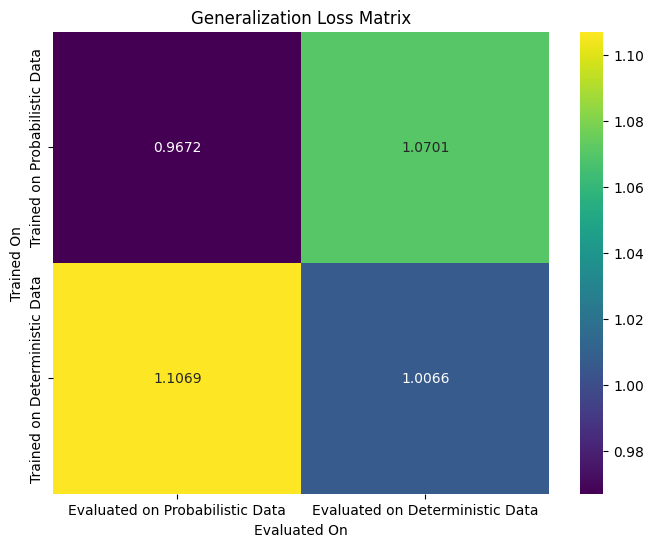

In [ ]:
#@title Plot Generalization Loss Matrix!

#@markdown What have we learned?

#@markdown There is a much bigger difference between human behavior on probabilistic and deterministic tasks than there was depending on what was visible on screen.

# Construct the 2x2 matrix for generalization scores.
generalization_loss_matrix = [
    [in_sample_test_loss[0], out_sample_test_loss[0]],
    [out_sample_test_loss[1], in_sample_test_loss[1]]
]

# Define the labels for the x and y axes
x_labels = ['Evaluated on Probabilistic Data', 'Evaluated on Deterministic Data']
y_labels = ['Trained on Probabilistic Data', 'Trained on Deterministic Data']

plt.figure(figsize=(8, 6))
sns.heatmap(generalization_loss_matrix, annot=True, fmt=".4f", cmap="viridis",
            xticklabels=x_labels, yticklabels=y_labels)
plt.title('Generalization Loss Matrix')
plt.xlabel('Evaluated On')
plt.ylabel('Trained On')
plt.show()

In [ ]:
#@title What does the neural net tell us, then?

#@markdown It tells us that human behavior changes more meaningfully when the type of learning environment changes, than when the superficial task features change.

#@markdown What it doesn't tell us, though, is *what* changes *about the behavior.*

#@markdown How can we figure that out? Through more traditional computational models of behavior.

In [ ]:
#@title Traditional computational models of behavior!

# First, let's define a Q-learner model based on how it "behaves" on one of our bandit tasks.
def simulate_Q_learner(parameters, states, arm_outcomes, n_choices):
  # Define parameters for our Q-learner.
  alpha = parameters[0] # The learning rate. MUST be between 0 and 1.
  beta = parameters[1] # The inverse temperature parameter for the softmax. (Higher beta -> less decision noise)
  # Beta MUST be positive.

  # A small, but non-zero value for buffering against dividing by 0.
  non_zero_zero = 1e-9

  # Initialize uniform Q-values, using max_n_states to ensure enough space
  Qs = np.ones((max_n_states,n_choices))/n_choices

  # "Make choice" for 0th trial.
  state = states[0]
  p_choices = scipy.special.softmax(Qs[state]/(beta+non_zero_zero))
  choice = np.random.choice(np.arange(n_choices), p=p_choices)
  choices = np.array([choice])
  reward = arm_outcomes[0][choice]/100
  rewards = np.array([reward*100])
  best_choice = np.argmax(arm_outcomes[0])

  # Initialize learning curves per state, using max_n_states
  state_based_learning_curves = [[] for _ in range(max_n_states)]
  state_based_learning_curves[state].append(choice==best_choice)

  # Loop over other trials in the session.
  for trial in range(1,len(states)):

    # Learn!
    Qs[state][choice] = Qs[state][choice] + alpha * (reward - Qs[state][choice])

    # Encounter next state and make next choice!
    state = states[trial]
    p_choices = scipy.special.softmax(Qs[state]/(beta+non_zero_zero))
    choice = np.random.choice(np.arange(n_choices), p=p_choices)
    choices = np.concatenate((choices,np.array([choice])))

    # Grade the choice to make a learning curve out of it
    best_choice = np.argmax(arm_outcomes[trial])
    state_based_learning_curves[state].append(choice==best_choice)

    # Get next reward... so that we can learn from it on next trial.
    reward = arm_outcomes[trial][choice]/100
    rewards = np.concatenate((rewards,np.array([choice])))

  return rewards, choices, state_based_learning_curves


# Second, let's define a function for fitting parameters to a Q-learner model.
def nllh_Q_learner(parameters, states, rewards, choices, n_choices):
  # Define parameters for our Q-learner.
  alpha = parameters[0] # The learning rate. MUST be between 0 and 1.
  beta = parameters[1] # The inverse temperature parameter for the softmax. (Higher beta -> less decision noise)
  # Beta MUST be positive.

  non_zero_zero = 1e-9

  # Initialize uniform Q-values, using max_n_states to ensure enough space
  Qs = np.ones((max_n_states,n_choices))/n_choices

  # "Make choice" for 0th trial.
  state = states[0]
  p_choices = scipy.special.softmax(Qs[state]/(beta+non_zero_zero))
  choice = choices[0]
  llh = np.log(p_choices[choice]+non_zero_zero)
  reward = rewards[0]/100

  # Loop over other trials in the session.
  for trial in range(1,len(states)):

    # Learn!
    Qs[state][choice] = Qs[state][choice] + alpha * (reward - Qs[state][choice])

    # Encounter next state and make next choice!
    state = states[trial]
    p_choices = scipy.special.softmax(Qs[state]/(beta+non_zero_zero))
    choice = choices[trial]
    llh += np.log(p_choices[choice]+non_zero_zero)

    # Get next reward... so that we can learn from it on next trial.
    reward = rewards[trial]/100

  nllh = -llh
  return nllh

In [ ]:
#@title Fitting a traditional computational model of behavior: A Q-learner!

# First, let's trim down the number of total sessions to fit per condition.
# These Q-learners take more time to fit than neural nets do, because we're no longer applying straightforward gradient descent.
# Nor are we using Jax... yet.

n_sessions_to_fit = 10
n_total_sessions = len(data)
n_starting_points = 10

# We're going to use a 2-parameter Q-learner with learning rate alpha and inverse temperature parameter beta.
# Specify reasonable bounds on alpha and beta.
bounds = [(0.0, 1.0),(1e-9, 100.0)]
n_params = len(bounds)

# Use random.sample to select unique numbers without replacement
random_session_numbers = random.sample(range(n_total_sessions), n_sessions_to_fit)
data_to_fit = data.iloc[random_session_numbers]

for run in data_to_fit['run']:
  session_data = data_to_fit.loc[data_to_fit['run'] == run]
  n_arms = int(session_data['n_actions'].values[0])
  states = session_data['states'].values[0]
  arm_outcomes = session_data['arm_outcomes'].values[0]

  # Simulate choices that a Q-learner would make.
  real_alpha, real_beta = 0.15, 85
  rewards, choices, learning_curves = simulate_Q_learner([real_alpha, real_beta],states,arm_outcomes,n_arms)

  nllhs, params = [], []

  # Fit those choices and rewards to find the values of alpha and beta that they were simulated with.
  for nii in range(n_starting_points):
    # Initialize each search with random parameter guesses.
    initial_params = [random.gauss(0.1,sigma=0.05), random.gauss(80.0,5.0)]
    result = scipy.optimize.minimize(
        nllh_Q_learner,
        initial_params,
        args=(states,rewards,choices,n_arms),
        method='L-BFGS-B',
        bounds=bounds
    )
    nllhs.append(result.fun)
    params.append(result.x)

  best_one = np.argmin(nllhs)
  print(f'Best parameters: {params[best_one]}')
  print(f'True parameters: {real_alpha, real_beta}')


Best parameters: [ 0.14278341 70.58381983]
True parameters: (0.15, 85)
Best parameters: [ 0.37294908 84.96116864]
True parameters: (0.15, 85)
Best parameters: [1.         0.43084794]
True parameters: (0.15, 85)
Best parameters: [0.26722959 0.24425271]
True parameters: (0.15, 85)
Best parameters: [3.06421473e-02 7.38413403e+01]
True parameters: (0.15, 85)
Best parameters: [ 0.13837536 71.00812642]
True parameters: (0.15, 85)
Best parameters: [ 0.         87.48622393]
True parameters: (0.15, 85)
Best parameters: [ 0.16033635 75.77010561]
True parameters: (0.15, 85)
Best parameters: [6.36916091e-02 6.74671282e+01]
True parameters: (0.15, 85)
Best parameters: [ 0.7083453  74.47789258]
True parameters: (0.15, 85)


In [ ]:
#@title Defining a model of **how** behavior differs on one task set versus another.

# What might change about human behavior on deterministic vs. probabilistic tasks?
# Perhaps the speed of learning? How forgetful people are? How noisy in their decisions?
# How might you instantiate and test each of those hypotheses?

def nllh_Q_learner_mechanism(parameters, states, rewards, choices, n_choices):
  # Define parameters for our Q-learner.
  alpha = parameters[0] # The learning rate. MUST be between 0 and 1.
  beta = parameters[1]*100 # The inverse temperature parameter for the softmax. (Higher beta -> less decision noise)
  # Beta MUST be positive. Here I'm also transforming beta to be 100x higher than whatever the search is trying to fit.
  forgetting = parameters[2] # A forget rate applied to Q-values. MUST be between 0 and 1.

  non_zero_zero = 1e-9

  # Initialize uniform Q-values, using max_n_states to ensure enough space
  Q0 = np.ones((max_n_states,n_choices))/n_choices
  Qs = Q0.copy()

  # "Make choice" for 0th trial.
  state = states[0]
  p_choices = scipy.special.softmax(Qs[state]/(beta+non_zero_zero))
  choice = choices[0]
  llh = np.log(p_choices[choice]+non_zero_zero)
  reward = rewards[0]/100

  # Loop over other trials in the session.
  for trial in range(1,len(states)):

    # Learn!
    Qs[state][choice] = Qs[state][choice] + alpha * (reward - Qs[state][choice])

    # Forget everything! (Just a little bit...)
    Qs = (1-forgetting) * Qs + forgetting * Q0

    # Encounter next state and make next choice!
    state = states[trial]
    p_choices = scipy.special.softmax(Qs[state]/(beta+non_zero_zero))
    choice = choices[trial]
    llh += np.log(p_choices[choice]+non_zero_zero)

    # Get next reward... so that we can learn from it on next trial.
    reward = rewards[trial]/100

  nllh = -llh
  return nllh

In [ ]:
#@title Fitting a model of **how human behavior differs from one task set to another**.

# Choose the number of sessions to fit, and the number of random search starting points per session.
n_sessions_to_fit = 5
n_probabilistic_tasks = len(data_probabilistic)
n_deterministic_tasks = len(data_deterministic)
n_starting_points = 10

# Use random.sample to select unique numbers without replacement
random_session_numbers = random.sample(range(n_probabilistic_tasks), n_sessions_to_fit)
data_to_fit_1 = data_probabilistic.iloc[random_session_numbers]

random_session_numbers = random.sample(range(n_deterministic_tasks), n_sessions_to_fit)
data_to_fit_2 = data_deterministic.iloc[random_session_numbers]

data_to_fit = pd.concat([data_to_fit_1, data_to_fit_2])

# Note the bounds have beta for changed.
# This is because some optimizers work better if all parameters are in a similar range of values to discover.
bounds = [(0.0, 1.0), (1e-9, 1.0), (0.0, 1.0)]
n_params = len(bounds)
counter = 0

for index, session_data in data_to_fit.iterrows():
  # No more simulating choices - use real human choices instead!
  n_arms = int(session_data['n_actions'])
  states = session_data['states']
  rewards = session_data['rewards']
  choices = session_data['choices']
  arm_outcomes = session_data['arm_outcomes']

  nllhs, params = [], []

  # Fit those choices and rewards to find the values of alpha and beta that they were simulated with.
  for nii in range(n_starting_points):
    # Initialize each search with random parameter guesses.
    initial_params = [random.gauss(0.1,sigma=0.05), random.gauss(0.1,sigma=0.05), random.gauss(0.1,sigma=0.05)]
    result = scipy.optimize.minimize(
        nllh_Q_learner_mechanism,
        initial_params,
        args=(states,rewards,choices,n_arms),
        method='L-BFGS-B',
        bounds=bounds
    )
    nllhs.append(result.fun)
    params.append(result.x)

  if (counter%(n_sessions_to_fit) == 0) and counter<n_sessions_to_fit:
    print('For probabilistic tasks:')
  elif (counter%(n_sessions_to_fit) == 0) and counter>=n_sessions_to_fit:
    print('For deterministic tasks:')
  counter += 1

  best_one = np.argmin(nllhs)
  print(f'Best parameters: {params[best_one]*[1,100,1]}')


For probabilistic tasks:
Best parameters: [0.36610253 0.23795599 0.00410779]
Best parameters: [0.27143918 0.36230742 0.        ]
Best parameters: [0.59222298 0.24293924 0.        ]
Best parameters: [0.72993271 0.2929135  0.        ]
Best parameters: [0.33661664 0.1364464  0.05202738]
For deterministic tasks:
Best parameters: [0.70903209 0.10334888 0.01800014]
Best parameters: [0.00017166 0.00013873 0.03753682]
Best parameters: [0.6714113  0.16200421 0.05515671]
Best parameters: [2.37931638e-04 6.86402349e-05 2.00644649e-01]
Best parameters: [0.00062379 0.00043828 0.10074917]


In [ ]:
#@title If you've made it to this point, you've officially completed the workshop!

#@markdown Congrats!

#@markdown Now, have some fun! What questions do you have that might be answered by this dataset?
#@markdown Can you ask them with the methods we've learned to use today?
#@markdown Don't hesitate to ask me any remaining questions you might have.

#@markdown This code is yours now, so please use it, hack it apart, put it back together again, and let me know what you do with it!

In [ ]:
#@title Yet ANOTHER bonus question.

#@markdown Bored? How about working on this...?

#@markdown The models above don't recover all that well. What can we do to improve them?

#@markdown You can try:
#@markdown 1. Changing optimizers,
#@markdown 2. Increasing the number of random starting points for the search,
#@markdown 3. Changing the range of values of parameters
#@markdown 4. Re-formulating the models...
#@markdown 5. Etc!